In [ ]:
import os
import sys
import time as tym
import datetime
import math
import random
import pickle
import statistics as stat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

# Scientific & Geospatial Libraries
import mpmath
import netCDF4 as nc
import geopy.distance
from shapely.geometry import Point, Polygon
from global_land_mask import globe
import statsmodels.api as sm
from patsy import dmatrices

# Statistical Distributions
from scipy.optimize import curve_fit
from scipy.stats import burr, lognorm, beta
from fitter import Fitter, get_common_distributions, get_distributions
import numdifftools as nd

# --- CONFIGURATION ---
# Set the path to your data folder. Defaults to local 'data' folder if env var not set.
TC_DATA_DIR = os.getenv("TC_DATA_DIR", "./data")
MPI_DIR = os.path.join(TC_DATA_DIR, "mpi_out")

print(f"Loading data from: {TC_DATA_DIR}")

# --- LOAD DATASETS ---
# Helper function to load safely
def load_pickle(filename):
    path = os.path.join(TC_DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Warning: {filename} not found in {TC_DATA_DIR}")
        return None
    with open(path, "rb") as f:
        return pickle.load(f)

# Load Pickled Data
data = load_pickle("LMItracks.pkl")
datalandfall = load_pickle("LMItracks_landfall.pkl")

# Load Statistics / Distributions
XX = load_pickle("XX")
XX_fs = load_pickle("XX_fs")
XX_ms = load_pickle("XX_ms")
XX_nr = load_pickle("XX_nr")
mix_lognorm_ratio_near_land = load_pickle("mix_lognorm_ratio_near_land")
proba_mix_lognorm_ratio = load_pickle("proba_mix_lognorm_ratio")
mix_lognorm_ratio_mid_sea = load_pickle("mix_lognorm_ratio_mid_sea")
mix_lognorm_ratio_far_sea = load_pickle("mix_lognorm_ratio_far_sea")

# Load External Datasets (NetCDF / CSV / Excel)
try:
    datana = nc.Dataset(os.path.join(TC_DATA_DIR, "IBTrACS_TRMM_SHIPS_NA_LFR.nc"))
    ELI = pd.read_excel(os.path.join(TC_DATA_DIR, "ELI_ERSSTv5_1854.01-2020.05.xlsx"))
    ibdf = pd.read_csv(os.path.join(TC_DATA_DIR, 'ibtracs.since1980.list.v04r00.csv'), low_memory=False)
except FileNotFoundError as e:
    print(f"Critical Data Missing: {e}")

# Extract Arrays if data loaded successfully
if data:
    data_lon = np.array(data.lon)
    data_lat = np.array(data.lat)
    basin = np.array(data.basin)
    time = np.array(data.time)
    name = np.array(data.name)
    vmax = np.array(data.vmax)
if 'ibdf' in locals():
    isotime = np.array(ibdf.ISO_TIME)

In [46]:
plt.rcParams['figure.dpi'] = 1000

In [5]:
def windspeed_decay4(kappa,V0,T,d,dt, s): #windspeed decay case where alpha=0
    
    if s[0]==0 and s[1]==0:
        wind_speed_cut_off=0 #wind speed value from which the storm is not considered a TC anymore (in [m.s^-1])
    else:
        wind_speed_cut_off=18
        
    Vm=[] #wind speed of the storm at every time step
    Vm.append(V0)
    siz=1
    time=np.linspace(0,T,int(T/dt+1))
    kappa_land=5*10**(-7) #the value kappa takes when the storm reaches the land
    count=0; #count that will help run the simulation when storm is over landfall
    
    #here we treat the problem as follows: we separate in a discrete way the behaviour of the storm when above the ocean and above the land.
    #When above the ocean: kappa and alpha vary lognormal distribution. When reaching the landfall alpha=0, kappa=kappa_land and is varied following lognormal distribution.
    #When eventually reaching again ocean the last kappas and alphas used right before the storm reached land are reused to perturbed again alpha and kappa above ocean
    #etc... until the end of the simulation
    #print(time)
    #print(d)
    for step in range (1,len(time)):
        if d[step]==0:
            if count==0:
                kappa=kappa_land
            
            one_over_Vm=1/Vm[step-1]+kappa*dt
            
            Vm.append(1/one_over_Vm)
            count+=1
            
        else:
            if count!=0: #if it shiftes from land to ocean
                one_over_Vm=1/Vm[step-1]+kappa*dt
                
                Vm.append(1/one_over_Vm)
                count=0
            else:
                one_over_Vm=1/Vm[step-1]+kappa*dt
                
                Vm.append(1/one_over_Vm)
        if Vm[step]<wind_speed_cut_off: #the simulation ends if the computed wind speed is less than the cut off
            break
            Vm.pop()
    return Vm, time[0:len(Vm)]

In [6]:
def decay_eq_no_alpha(time, kappa):
    return np.array([1/V0+kappa*t for t in time] )

In [7]:
def extract_speed_time_landfall_lon_lat (storm_data, storm_number):
   #definition of conversion parameters
   knots_to_ms=0.51 
   knots_to_mh=1852
   hrs_to_sec=3600
   #it seems that the data is always observed given a fixed timestep, we find this fixed timestep named Delta here 
   if pd.Timestamp(np.array(storm_data.time)[storm_number][1]).hour<pd.Timestamp(np.array(data.time)[storm_number][2]).hour:
       Delta=pd.Timestamp(np.array(storm_data.time)[storm_number][2]).hour-pd.Timestamp(np.array(storm_data.time)[storm_number][1]).hour
   else:
       Delta=pd.Timestamp(np.array(storm_data.time)[storm_number][2]).hour+24-pd.Timestamp(np.array(storm_data.time)[storm_number][1]).hour

   #assigning the time in hrs from the LMI to the end of the storm given the DELTA timestep acquisition of the data
   times=hrs_to_sec*np.array([i*Delta for i in range(len(np.array(storm_data.time)[storm_number]))])
   d_landfall=np.array(storm_data.landfall)[storm_number]
   #assigning the storm's maximum wind speed near the surface and converting into m.s^(-1)
   Vm=np.array(knots_to_ms*np.array(data.vmax)[storm_number])
   lon=np.array(data.lon)[storm_number]
   lat=np.array(data.lat)[storm_number]

   #checking if there are Nan values
   index_nan1=np.array(np.argwhere(np.isnan(Vm)))
   index_nan=[]
   for i in range (len(index_nan1)):
       index_nan.append(index_nan1[i][0])

   #if actually there are NaN value in Vm, remove them and remove the associated time in variable times
   if len(index_nan)!=0: 
       index_first_nan=index_nan[0]
       for i in range (len(times)-index_first_nan):
           times=np.delete(times,-1)

       nan_array=np.isnan(Vm)
       not_nan_array=~nan_array
       Vm=Vm[not_nan_array]
       lon=lon[not_nan_array]
       lat=lat[not_nan_array]
       d_landfall=d_landfall[not_nan_array]

   return times, d_landfall, Vm, Delta, lon,lat

In [8]:
def lat_lon_extrapolation(last_lat_in,last_lon_in):
    last_lon=last_lon_in.copy()
    last_lat=last_lat_in.copy()

    b1=True
    b2=True

    if last_lon[len(last_lon)-1]>0 and last_lon[0]<0 and abs(last_lon[len(last_lon)-1])>150:
        #print(np.where(np.array(last_lon)>0)[0])
        if len(np.where(np.array(last_lon)>0)[0])>1:
            idx_shift=np.where(np.array(last_lon)>0)[0][0]
            vec0=last_lon[len(last_lon)-1]-last_lon[idx_shift]
            lon_extrapolated=last_lon[len(last_lon)-1]+vec0/(len(last_lon[idx_shift:len(last_lon)-1]))
        else:
            #print("hellpo")
            last_lon[-2]=last_lon[-2]+360
            vec0=last_lon[len(last_lon)-1]-last_lon[-2]
            lon_extrapolated=last_lon[len(last_lon)-1]+vec0
        b1=False
        
        
    elif last_lon[len(last_lon)-1]<0 and last_lon[0]>0 and abs(last_lon[len(last_lon)-1])>150:
        #print(np.where(np.array(last_lon)<0)[0])
        if len(np.where(np.array(last_lon)<0)[0])>1:
            idx_shift=np.where(np.array(last_lon)<0)[0][0]
            vec0=last_lon[len(last_lon)-1]-last_lon[idx_shift]
            lon_extrapolated=last_lon[len(last_lon)-1]+vec0/(len(last_lon[idx_shift:len(last_lon)-1]))
        else:
            #print("hellpo")
            last_lon[-2]=last_lon[-2]-360
            vec0=last_lon[len(last_lon)-1]-last_lon[-2]
            lon_extrapolated=last_lon[len(last_lon)-1]+vec0
        b1=False
        
        
    if last_lat[len(last_lat)-1]>0 and last_lat[0]<0 and abs(last_lat[len(last_lat)-1])>70:
        if len(np.where(np.array(last_lat)>0)[0])>1:
            idx_shift=np.where(np.array(last_lat)>0)[0][0]
            vec1=last_lat[len(last_lat)-1]-last_lat[idx_shift]
            lat_extrapolated=last_lat[len(last_lat)-1]+vec1/(len(last_lat[idx_shift:len(last_lat)-1]))
        else:
            last_lat[-2]=-last_lat[-2]
            vec1=last_lat[len(last_lat)-1]-last_lat[-2]
            lat_extrapolated=last_lat[len(last_lat)-1]+vec1
        b2=False
        
        
    elif last_lat[len(last_lat)-1]<0 and last_lat[0]>0 and abs(last_lat[len(last_lat)-1])>70:
        if len(np.where(np.array(last_lat)<0)[0])>1:
            idx_shift=np.where(np.array(last_lat)<0)[0][0]
            vec1=last_lat[len(last_lat)-1]-last_lat[idx_shift]
            lat_extrapolated=last_lat[len(last_lat)-1]+vec1/(len(last_lat[idx_shift:len(last_lat)-1]))
        else:
            last_lat[-2]=-last_lat[-2]
            vec1=last_lat[len(last_lat)-1]-last_lat[-2]
            lat_extrapolated=last_lat[len(last_lat)-1]+vec1
        b2=False
        
        
    if b1==True and b2==True:
        vec=[last_lon[len(last_lon)-1]-last_lon[0],last_lat[len(last_lat)-1]-last_lat[0]]
        lat_extrapolated=last_lat[len(last_lat)-1]+vec[1]/(len(last_lat)-1)
        lon_extrapolated=last_lon[len(last_lon)-1]+vec[0]/(len(last_lon)-1)
    elif b1==True and b2==False:
        vec0=last_lon[len(last_lon)-1]-last_lon[0]
        lon_extrapolated=last_lon[len(last_lon)-1]+vec0/(len(last_lon)-1)
    elif b1==False and b2==True:
        vec1=last_lat[len(last_lat)-1]-last_lat[0]
        lat_extrapolated=last_lat[len(last_lat)-1]+vec1/(len(last_lat)-1)

    if lon_extrapolated>180:
        lon_extrapolated=lon_extrapolated-360
    if lon_extrapolated<-180:
        lon_extrapolated=360+lon_extrapolated
    if lat_extrapolated>90:
        lat_extrapolated=180-lat_extrapolated
    if lat_extrapolated<-90:
        lat_extrapolated=-(180+lat_extrapolated)


    return lon_extrapolated,lat_extrapolated

In [9]:
def extract_random_alpha_av_r34(Vm): 
   R34=beta.rvs(4.556555177676001, 5240.635905082121, 0.13188143885506104, 104237.26144450743)
   alpha=burr.rvs(4.8254278183524315, 0.4856593590267311, 0, 0.601076373081717)
   while alpha<0:
      alpha=burr.rvs(4.8254278183524315, 0.4856593590267311, 0, 0.601076373081717)
   RMW=R34*(34*0.514/Vm)**(1/alpha)
   return alpha, R34, RMW

In [59]:
def trackdev2(num_of_trials, p_lats, p_lons,ratio_lmi_mpi,kapa,kapa_land,mpi_lon_initial,mpi_lat_initial,storm_time,mpi_index_initial,storm_number,basin_parent):     
    #num_of_trials is the number of simulated storms per parent track. p_lats is the lat locations of the parent track. p_lons is the lon locations of the parent track. lmi is the lmi generated for each new storm. kappa and kappa_land are the generated kappas for each new storm.
    #print(storm_time)
    basin_names = np.array(['EP', 'NA', 'NI',
                'SI', 'SP', 'WP'])

    # Empty lists to save the new extrapolated latitiude and longitude positions of the parent track if neccessary.
    extrap_parent_lons = []     
    extrap_parent_lats = []


    mpi_thresh = 1000

    length_of_points = len(p_lons) # Saves the length of the array of parent lat and lon.

    dist_from_lf = []  # Empty list to store the distance form landfall for each simulated storm.

    sim_lats = []   
    # Empty list to store the all the latitude and longitude locations for each simulated storm.
    sim_lons = []

    lf_lon_point = []   # Emppty list to store the initial landfall latitude and longitude position.
    lf_lat_point = []

    dt = 3*3600

    Vm = []     # Empty list to store the Vmax decay for each simulated storm.

    wind_profile=[] #this array will gather all the wind speed profile of each deviated storm for every point over land; the arrays inside will be empty if the storms are over ocean

    rad = 2     
    # Sets the radius of initial position shift in degrees.

    # Creates a random unit vector with normal distribution of magnitude about 0 for the offset of the genesis postion.
    phi_initial = 2*np.pi*np.random.random(num_of_trials)   # Creates an array of uniformly distributed angles between 0 and 2pi.
    r_initial = np.random.uniform(0,rad,size = num_of_trials)   # Creates an array of uniformaly distributed magnitudes between 0 and 2 degrees.
    xvec_initial = r_initial*np.cos(phi_initial)    # Finds the x and y (lon and lat) vector for each pair of angle and magnitudes in the arrays above.
    yvec_initial = r_initial*np.sin(phi_initial)

    # Creates a random unit vector with normal distribution of magnitude about 0 to deviate simulated storm positions.
    phi = 2*np.pi*np.random.random(num_of_trials)   # Creates an array of uniformly distributed angles between 0 and 2pi.
    r = np.random.normal(loc=0,scale=0.01,size=num_of_trials)   # Creates an array of normally distributed magnitudes about 0.
    xvec = r*np.cos(phi)    # Finds the x and y (long and lat) vector for each pair of angle and magnitudes in the arrays above.
    yvec = r*np.sin(phi)


    for n in range(0,num_of_trials):
        #print

        ###MPI around in the month and basin of the parent storm before shifting
        mpi_lon = mpi_lon_initial
        #print("lons_mpi_initial",mpi_lon)
        mpi_lat = mpi_lat_initial
        #print("lat_mpi_initial",mpi_lon)
        mpi_index = mpi_index_initial

        ### so far a basin and mpi have been found for the parent storm
        boole_basin=True
        boole_mpi=True

        # Shifts the genesis postion of the simulated stormby adding the random genesis shift vector to each point in the parent track.
        parent_lats = (p_lats+yvec_initial[n]).tolist()     
        parent_lons = (p_lons+xvec_initial[n]).tolist()

        # Saves the initial lat and lon position of the parent track.
        initial_lon = parent_lons[0]    
        initial_lat = parent_lats[0]


        #print('basin_parent',basin_parent)
        bas_shift, boole_basin=find_basin(parent_lons[0],parent_lats[0],basin_parent)
        new_basin_deviated_storm=bas_shift
        #print('bas_shift',basin_names[bas_shift])
        sim_time = [pd.to_datetime(storm_time[0])]

        #if the new basin is different from the parent basin, find the new mpi corresponding array
        if basin_names[bas_shift] != basin_parent:
            print('basin change after shift new and old',bas_shift,basin_parent)

            mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[0].month,basin_names[bas_shift])


            print("The storm changed basin in its initial shift")

            #print("lons",mpi_lon)
            #print("lats",mpi_lat)
            if boole_mpi==False: #if an mpi could not been found we do not shift the initial storm
                print("but returned to the parent storm initial position")
                initial_lon=p_lons[0]
                initial_lat=p_lats[0]
                print(basin_parent)
                print(sim_time[0].month)
                mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[0].month,basin_parent)

                print(boole_mpi)





        #find the indexs in the mpi array corresponding to the shifted storm initial mpi
        if parent_lons[0]<0:
            lon_point=360+parent_lons[0]
            if lon_point>mpi_lon[len(mpi_lon)-1] and lon_point<mpi_lon[len(mpi_lon)-1]+1:
                ind_lon=len(mpi_lon)-1
            elif lon_point<mpi_lon[0] and lon_point>mpi_lon[0]-1:
                ind_lon=0
            else:
                print(lon_point,mpi_lon)
                ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point][0]

        else:
            if initial_lon>mpi_lon[len(mpi_lon)-1] and initial_lon<mpi_lon[len(mpi_lon)-1]+1:
                ind_lon=len(mpi_lon)-1
            elif initial_lon<mpi_lon[0] and initial_lon>mpi_lon[0]-1:
                ind_lon=0
            else:

                ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>initial_lon][0]
            #print("indexMPI",ind_lon)
        #print(mpi_lat)
        #print(ind_lat)



        if abs(initial_lat)<5.5:
            ind_lat=len(mpi_lat)-1
        elif abs(initial_lat)>59:
            ind_lat=0
        else:
            # print(dev_lat_point[i+1],mpi_lat)
            ind_lat=[idx for idx,val in enumerate(mpi_lat) if val<initial_lat][0]

        #updating the lmi after the storm's shift 
        Pmpi_initial=mpi_index[ind_lat,ind_lon]
        Vmpi_initial=3.4*(1010-Pmpi_initial)**(0.644)


        lmi=ratio_lmi_mpi*Vmpi_initial



    #array that will contain all the array recording the wind speed value recorde every 25 km from RMW for all points where the storm was over land; if no points were over land the array will be an array of empty arrays
        wind_profile_for=[] 



        # Checks whether the initial position of the parent storm is outside the convention and if so, corrects it.
        if parent_lons[0]>180:    
            initial_lon = parent_lons[0]-360
        if parent_lons[0]<-180:
            initial_lon = 360 + parent_lons[0]
        if parent_lats[0] > 90:
            initial_lat = 180 - parent_lats[0]
        if parent_lats[0] < -90:
            initial_lat = -(180 + parent_lats[0])

        dev_lon_point = [initial_lon]   # Saves the initial lat and lon position of the shifted parent track as the first lat and lon position of the simulated track.
        dev_lat_point = [initial_lat]

        Vm_for=[lmi]    # Saves the first value of Vmax as lmi passed into the function.

        kappa=kapa[n]      # Resets kappa to kappa over sea.
        kappa_land=kapa_land[n]
        lf_marker = 0   # Resets the landfall indicator back to 0.


        dist_from_lf_for = [1]  
    # Sets the first value of distance from land (0) to over sea (1).

        i = 0   # Resets counter.

        extrap_parent_lon = parent_lons     # This sets the first values in the extrapolated lon and lat lists to the same as the parent track.
        extrap_parent_lats = parent_lons



    # This is the while loop that passes thorugh each position of the parent track and deviates the position creating a new simulated track. This loop continues until the storms intensity drops below 18m/s.

        while Vm_for[i]>=18:

            wind_profile_for_for=[] #wind_profile_for_for array will contain the wind speed value recorde every 25 km from RMW if the actual point is over land; if not array will stay empty

            offlon = xvec[n]*2*(0.95*math.exp(0.035*(i+1))-0.95)/0.037   
    # This is function that calculates the amount of deviation at each point, it uses the lon and lat vectors calculated above to dictate the magnitude of the exponential increase in deviation.
            offlat = yvec[n]*2*(0.95*math.exp(0.035*(i+1))-0.95)/0.037


    # This statement checks if the simulated storm survives past the parent storm and if so, passess the last 5 locations of the parent track to the extrapolation function which returns and new extrapolated position that is appended to the parent track.
            if i>=length_of_points-1:
                lon_extrap,lat_extrap=lat_lon_extrapolation(parent_lats[-5:len(parent_lats)], parent_lons[-5:len(parent_lons)])
                parent_lons.append(lon_extrap) # Adds the extrapolation to each parent lat and lon at each time interval.
                parent_lats.append(lat_extrap)

            dev_lon_point.append(parent_lons[i+1]+offlon) # Adds the deviation calculated above to each parent lat and lon at each time interval.
            dev_lat_point.append(parent_lats[i+1]+offlat)

            # Checks whether the deviated lat or lon is outside the convention, and if so cerrects the location.
            if dev_lon_point[i+1]>180:    
                dev_lon_point[i+1] = dev_lon_point[i+1]-360
            if dev_lon_point[i+1]<-180:
                dev_lon_point[i+1] = 360 + dev_lon_point[i+1]
            if dev_lat_point[i+1] > 90:
                dev_lat_point[i+1] = 180 - dev_lat_point[i+1]
            if dev_lat_point[i+1] < -90:
                dev_lat_point[i+1] = -(180 + dev_lat_point[i+1])

            if abs(dev_lon_point[i+1])>180 or abs(dev_lat_point[i+1])>90:   # This is a fail safe that checks if any points are still outside the convention and if so the loop is broken and the simulated storm is not generated.
                break

            #print(type(sim_time[i]))
            sim_time.append(sim_time[i]+datetime.timedelta(hours = 3))
            old_basin_deviated_storm=new_basin_deviated_storm
            #print("old_basin",old_basin_deviated_storm)
            new_basin_deviated_storm, boole_basin = find_basin(dev_lon_point[i+1],dev_lat_point[i+1],basin_names[old_basin_deviated_storm])
            #print("new basin", new_basin_deviated_storm)


            if sim_time[i+1].month != sim_time[i].month:
                #print('boo',sim_time[i+1].month,sim_time[i].month)
                mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[i+1].month,basin_names[new_basin_deviated_storm])

                print("MPI has changed month")
                #print(mpi_lon)
                #print(mpi_lat)


            if new_basin_deviated_storm != old_basin_deviated_storm :
                #print('boo',new_basin,basx)
                mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[i+1].month,basin_names[new_basin_deviated_storm])
                print("MPI has changed basin")
                print("from", basin_names[old_basin_deviated_storm], "to", basin_names[new_basin_deviated_storm])
                #print("lons",mpi_lon)
                #print("lats",mpi_lat)


            onland = globe.is_land(dev_lat_point[i+1],dev_lon_point[i+1])   # Checks whether each lat and lon point is over land or not.

            # If over land then the lf marker is set to 1 and the distance from landfall is now zero over land.
            if onland == True:
                dist_from_lf_for.append(0)  # Appends 0 to distance from landfall to indicate storm is over land.
                    ###wind footprint profile
                alpha,R34, RMW=extract_random_alpha_av_r34(Vm_for[i])
                wind_radius=Vm_for[i] ###wind speed at landfall
                wind_profile_for_for.append(wind_radius) 
                r=RMW #radius of maximum winds in km
                #counter=0
                count=0
                while wind_radius>18:
                    if alpha<0 or count>50:
                        print(alpha)
                        print(r)
                        print("R34",R34)
                    r=r+20 #add 20 km
                    wind_radius=34*0.514*(R34/r)**(alpha)
                    wind_profile_for_for.append(wind_radius)
                    count=count+1


                if lf_marker == 0:
                    lf_lon_point.append(dev_lon_point[i+1])     # Appends the landfall location.
                    lf_lat_point.append(dev_lat_point[i+1])
                lf_marker = 1   # Sets landfall indicator to 1.


                if abs(dev_lat_point[i+1])<7 or abs(dev_lat_point[i+1])>40:     # If the storm is outside 40˚ or within 7˚ of the equator then kappa is set to a large value to kill the intensity of the storm.
                    #print(Pmpi)
                    kap= np.random.uniform(5*(10*(-7)),10*(-6))
                    if abs(dev_lat_point[i+1])<5.5:
                        kap=10**(-5)
                    if kap>kappa_land:
                        kappa_land=kap
                one_over_Vm= 1/Vm_for[i]+kappa_land*dt   # one_over_Vm is used at the end of each loop to calculate Vmax.

            # If not over lad then the distance from landfall at each time interval location is 1.
            elif onland == False:  
                dist_from_lf_for.append(1)  # Appends 1 to distance from landfall to indicate storm is over sea.
                if boole_mpi==True: 
    #if it has found an mpi at the given location to check wether is above and adapt the decay


                    if dev_lon_point[i+1]<0:
                        lon_point=360+dev_lon_point[i+1]
                        if lon_point>mpi_lon[len(mpi_lon)-1] and lon_point<mpi_lon[len(mpi_lon)-1]+2:
                            ind_lon=len(mpi_lon)-1
                        else:
                            inds_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point]
                            if len(inds_lon)!=0:
                                ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point][0]
                            else:
                                print("weird1",mpi_lon)
                                print('weird1',lon_point)

                    else:

                        if dev_lon_point[i+1]>mpi_lon[len(mpi_lon)-1] and dev_lon_point[i+1]<mpi_lon[len(mpi_lon)-1]+1:
                            ind_lon=len(mpi_lon)-1
                        else:
                            # print(dev_lon_point[i+1],mpi_lon)
                            inds_lon=[idx for idx,val in enumerate(mpi_lon) if val>dev_lon_point[i+1]]
                            if len(inds_lon)!=0:
                                ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>dev_lon_point[i+1]][0]
                            else:
                                print("weird2")


                        #print("indexMPI",ind_lon)
                    #print(mpi_lat)
                    #print(dev_lat_point[i+1])


                    if abs(dev_lat_point[i+1])>55:
                        Pmpi=1200
                    else:
                        if abs(dev_lat_point[i+1])<5.5 :
                            ind_lat=len(mpi_lat)-1
                        # print(dev_lat_point[i+1],mpi_lat)
                        else:
                            ind_lat=[idx for idx,val in enumerate(mpi_lat) if val<dev_lat_point[i+1]][0]
                        Pmpi=mpi_index[ind_lat,ind_lon] 


                    if abs(dev_lat_point[i+1])<7 or Pmpi>mpi_thresh or dev_lat_point[i+1]<-45:     
    # If the storm is above the Pmpi threshold or within 7˚ of the equator then kappa is set to a large value to kill the intensity of the storm.

                        kappa = np.random.uniform(5*(10*(-7)),10*(-6))
                        if abs(dev_lat_point[i+1])<5.5:
                            kappa=10**(-5)
                    one_over_Vm= 1/Vm_for[i]+kappa*dt # one_over_Vm is used at the end of each loop to calculate Vmax.

                else:  
                    if abs(dev_lat_point[i+1])<7 or abs(dev_lat_point[i+1])>40:     # If the storm is outside 40˚ or within 7˚ of the equator then kappa is set to a large value to kill the intensity of the storm.

                        kappa = np.random.uniform(5*(10*(-7)),10*(-6))
                        if abs(dev_lat_point[i+1])<5.5:
                            kappa=10**(-5)
                    one_over_Vm= 1/Vm_for[i]+kappa*dt # one_over_Vm is used at the end of each loop to calculate Vmax.

            wind_profile_for.append(wind_profile_for_for)

            Vm_for.append(1/one_over_Vm)    # Vmax is calculated using one_over_Vm.

            i = i +1       # 1 is added to the counter.

        extrap_parent_lons.append(parent_lons)      # This saves the extrapolated track for each simulated storm.
        extrap_parent_lons.append(parent_lats)

        Vm.append(Vm_for)       
    # This saves the Vmax for each simulated storm.

        sim_lons.append(dev_lon_point)      # This saves the lat and lon locations for each simulated storm.
        sim_lats.append(dev_lat_point)

        wind_profile.append(wind_profile_for)

        dist_from_lf.append(dist_from_lf_for)   # This saves the distance from landfall for each simulated storm.

    return sim_lons,sim_lats,lf_lon_point,lf_lat_point,lf_marker,dist_from_lf, Vm, extrap_parent_lons,extrap_parent_lons,yvec,wind_profile

In [137]:
def trackdev(num_of_trials, p_lats, p_lons,ratio_lmi_mpi,kapa,kapa_land,mpi_lon_initial,mpi_lat_initial,storm_time,mpi_index_initial,storm_number,basin_parent):     
#num_of_trials is the number of simulated storms per parent track. p_lats is the lat locations of the parent track. p_lons is the lon locations of the parent track. lmi is the lmi generated for each new storm. kappa and kappa_land are the generated kappas for each new storm.
    #print(storm_time)
    basin_names = np.array(['EP', 'NA', 'NI',
                'SI', 'SP', 'WP'])
    
# Empty lists to save the new extrapolated latitiude and longitude positions of the parent track if neccessary.
    extrap_parent_lons = []     
    extrap_parent_lats = []


    mpi_thresh = 960

    length_of_points = len(p_lons) # Saves the length of the array of parent lat and lon.

    dist_from_lf = []  # Empty list to store the distance form landfall for each simulated storm.

    sim_lats = []   
# Empty list to store the all the latitude and longitude locations for each simulated storm.
    sim_lons = []

    lf_lon_point = []   # Emppty list to store the initial landfall latitude and longitude position.
    lf_lat_point = []

    dt = 3*3600

    Vm = []     # Empty list to store the Vmax decay for each simulated storm.

    wind_profile=[] #this array will gather all the wind speed profile of each deviated storm for every point over land; the arrays inside will be empty if the storms are over ocean

    rad = 2     
# Sets the radius of initial position shift in degrees.

    # Creates a random unit vector with normal distribution of magnitude about 0 for the offset of the genesis postion.
    phi_initial = 2*np.pi*np.random.random(num_of_trials)   # Creates an array of uniformly distributed angles between 0 and 2pi.
    r_initial = np.random.uniform(0,rad,size = num_of_trials)   # Creates an array of uniformaly distributed magnitudes between 0 and 2 degrees.
    xvec_initial = r_initial*np.cos(phi_initial)    # Finds the x and y (lon and lat) vector for each pair of angle and magnitudes in the arrays above.
    yvec_initial = r_initial*np.sin(phi_initial)

    # Creates a random unit vector with normal distribution of magnitude about 0 to deviate simulated storm positions.
    phi = 2*np.pi*np.random.random(num_of_trials)   # Creates an array of uniformly distributed angles between 0 and 2pi.
    r = np.random.normal(loc=0,scale=0.01,size=num_of_trials)   # Creates an array of normally distributed magnitudes about 0.
    xvec = r*np.cos(phi)    # Finds the x and y (long and lat) vector for each pair of angle and magnitudes in the arrays above.
    yvec = r*np.sin(phi)


    for n in range(0,num_of_trials):
        #print

        ###MPI around in the month and basin of the parent storm before shifting
        mpi_lon = mpi_lon_initial
        #print("lons_mpi_initial",mpi_lon)
        mpi_lat = mpi_lat_initial
        #print("lat_mpi_initial",mpi_lon)
        mpi_index = mpi_index_initial

        ### so far a basin and mpi have been found for the parent storm
        boole_basin=True
        boole_mpi=True

        # Shifts the genesis postion of the simulated stormby adding the random genesis shift vector to each point in the parent track.
        parent_lats = (p_lats+yvec_initial[n]).tolist()     
        parent_lons = (p_lons+xvec_initial[n]).tolist()

        # Saves the initial lat and lon position of the parent track.
        initial_lon = parent_lons[0]    
        initial_lat = parent_lats[0]


        #print('basin_parent',basin_parent)
        bas_shift, boole_basin=find_basin(parent_lons[0],parent_lats[0],basin_parent)
        new_basin_deviated_storm=bas_shift
        #print('bas_shift',basin_names[bas_shift])
        sim_time = [pd.to_datetime(storm_time[0])]

        #if the new basin is different from the parent basin, find the new mpi corresponding array
        if basin_names[bas_shift] != basin_parent:
            #print('boo',new_basin,basx)

            mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[0].month,basin_names[bas_shift])


            

            #print("lons",mpi_lon)
            #print("lats",mpi_lat)
            if boole_mpi==False: #if an mpi could not been found we do not shift the initial storm
                print("but returned to the parent storm initial position")
                initial_lon=p_lons[0]
                initial_lat=p_lats[0]
                mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[0].month,basin_parent)

                


                       
        #find the indexs in the mpi array corresponding to the shifted storm initial mpi
        if parent_lons[0]<0:
            lon_point=360+initial_lon
            inds_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point]
            if len(inds_lon)!=0:
                ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point][0]
            else:
                if mpi_lon[len(mpi_lon)-1]<lon_point:
                    ind_lon=len(mpi_lon)-1
                else:
                    ind_lon=0            
            
        else:
            inds_lon=[idx for idx,val in enumerate(mpi_lon) if val>initial_lon]
            if len(inds_lon)!=0:
                ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>initial_lon][0]
            else:
                if mpi_lon[len(mpi_lon)-1]<initial_lon:
                    ind_lon=len(mpi_lon)-1
                else:
                    ind_lon=0
                

        
        if abs(initial_lat)<5.5:
            ind_lat=len(mpi_lat)-1
        elif abs(initial_lat)>59:
            ind_lat=0
        else:
            ind_lat=[idx for idx,val in enumerate(mpi_lat) if val<initial_lat][0]

        #updating the lmi after the storm's shift 
        
        Pmpi_initial=mpi_index[ind_lat,ind_lon]
        Vmpi_initial=3.4*(1010-Pmpi_initial)**(0.644)
        lmi=ratio_lmi_mpi*Vmpi_initial
        #print("Vmpi_initial shifted",Vmpi_initial)



        
#array that will contain all the array recording the wind speed value recorde every 25 km from RMW for all points where the storm was over land; if no points were over land the array will be an array of empty arrays
        wind_profile_for=[] 



        # Checks whether the initial position of the parent storm is outside the convention and if so, corrects it.
        if initial_lon>180:    
            initial_lon = parent_lons[0]-360
        if initial_lon<-180:
            initial_lon = 360 + parent_lons[0]
        if initial_lat > 90:
            initial_lat = 180 - parent_lats[0]
        if initial_lat< -90:
            initial_lat = -(180 + parent_lats[0])

        dev_lon_point = [initial_lon]   # Saves the initial lat and lon position of the shifted parent track as the first lat and lon position of the simulated track.
        dev_lat_point = [initial_lat]

        Vm_for=[lmi]    # Saves the first value of Vmax as lmi passed into the function.

        kappa=kapa[n]      # Resets kappa to kappa over sea.
        kappa_land=kapa_land[n]
        lf_marker = 0   # Resets the landfall indicator back to 0.


        dist_from_lf_for = [1]  
# Sets the first value of distance from land (0) to over sea (1).

        i = 0   # Resets counter.

        extrap_parent_lon = parent_lons     # This sets the first values in the extrapolated lon and lat lists to the same as the parent track.
        extrap_parent_lats = parent_lons


        
# This is the while loop that passes thorugh each position of the parent track and deviates the position creating a new simulated track. This loop continues until the storms intensity drops below 18m/s.
        
        while Vm_for[i]>=18:

            wind_profile_for_for=[] #wind_profile_for_for array will contain the wind speed value recorde every 25 km from RMW if the actual point is over land; if not array will stay empty

            offlon = xvec[n]*2*(0.95*math.exp(0.035*(i+1))-0.95)/0.037
            # This is function that calculates the amount of deviation at each point, it uses the lon and lat vectors calculated above to dictate the magnitude of the exponential increase in deviation.
            offlat = yvec[n]*2*(0.95*math.exp(0.035*(i+1))-0.95)/0.037

            
                # This statement checks if the simulated storm survives past the parent storm and if so, passess the last 5 locations of the parent track to the extrapolation function which returns and new extrapolated position that is appended to the parent track.
            if i>=length_of_points-1:
                lon_extrap,lat_extrap=lat_lon_extrapolation(parent_lats[-5:len(parent_lats)], parent_lons[-5:len(parent_lons)])
                parent_lons.append(lon_extrap) # Adds the extrapolation to each parent lat and lon at each time interval.
                parent_lats.append(lat_extrap)

            dev_lon_point.append(parent_lons[i+1]+offlon) # Adds the deviation calculated above to each parent lat and lon at each time interval.
            dev_lat_point.append(parent_lats[i+1]+offlat)

            # Checks whether the deviated lat or lon is outside the convention, and if so cerrects the location.
            if dev_lon_point[i+1]>180:    
                dev_lon_point[i+1] = dev_lon_point[i+1]-360
            if dev_lon_point[i+1]<-180:
                dev_lon_point[i+1] = 360 + dev_lon_point[i+1]
            if dev_lat_point[i+1] > 90:
                dev_lat_point[i+1] = 180 - dev_lat_point[i+1]
            if dev_lat_point[i+1] < -90:
                dev_lat_point[i+1] = -(180 + dev_lat_point[i+1])

            if abs(dev_lon_point[i+1])>180 or abs(dev_lat_point[i+1])>90:   # This is a fail safe that checks if any points are still outside the convention and if so the loop is broken and the simulated storm is not generated.
                break

            #print(type(sim_time[i]))
            sim_time.append(sim_time[i]+datetime.timedelta(hours = 3))
            old_basin_deviated_storm=new_basin_deviated_storm
            #print("old_basin",old_basin_deviated_storm)
            new_basin_deviated_storm, boole_basin = find_basin(dev_lon_point[i+1],dev_lat_point[i+1],basin_names[old_basin_deviated_storm])
            #print("new basin", new_basin_deviated_storm)


            if sim_time[i+1].month != sim_time[i].month:
                #print('boo',sim_time[i+1].month,sim_time[i].month)
                mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[i+1].month,basin_names[new_basin_deviated_storm])
                
            
            change_basin=False
            if new_basin_deviated_storm != old_basin_deviated_storm :
                #print('boo',new_basin,basx)
                mpi_lon,mpi_lat,mpi_index, boole_mpi=MPI_extrap(data,storm_number,sim_time[i+1].month,basin_names[new_basin_deviated_storm])
                change_basin=True
#                 print("changed basin",boole_mpi)
#                 print("from", basin_names[old_basin_deviated_storm ], "to",basin_names[new_basin_deviated_storm] )
                    
                
            
            onland = globe.is_land(dev_lat_point[i+1],dev_lon_point[i+1])   # Checks whether each lat and lon point is over land or not.

            # If over land then the lf marker is set to 1 and the distance from landfall is now zero over land.
            if onland == True:
                dist_from_lf_for.append(0)  # Appends 0 to distance from landfall to indicate storm is over land.
                    ###wind footprint profile
                alpha,R34, RMW=extract_random_alpha_av_r34(Vm_for[i])
                wind_radius=Vm_for[i] ###wind speed at landfall
                wind_profile_for_for.append(wind_radius) 
                r=RMW #radius of maximum winds in km
                #counter=0
                count=0
                while wind_radius>18:
                    r=r+20 #add 20 km
                    wind_radius=34*0.514*(R34/r)**(alpha)
                    wind_profile_for_for.append(wind_radius)
                    count=count+1


                if lf_marker == 0:
                    lf_lon_point.append(dev_lon_point[i+1])     # Appends the landfall location.
                    lf_lat_point.append(dev_lat_point[i+1])
                lf_marker = 1   # Sets landfall indicator to 1.


                if abs(dev_lat_point[i+1])<7 or abs(dev_lat_point[i+1])>40:     # If the storm is outside 40˚ or within 7˚ of the equator then kappa is set to a large value to kill the intensity of the storm.
                    #print(Pmpi)
                    kap= np.random.uniform(5*(10*(-7)),10*(-6))
                    if abs(dev_lat_point[i+1])<5.5:
                        kap=10**(-5)
                    if kap>kappa_land:
                        kappa_land=kap
                one_over_Vm= 1/Vm_for[i]+kappa_land*dt   # one_over_Vm is used at the end of each loop to calculate Vmax.

            # If not over lad then the distance from landfall at each time interval location is 1.
            else:  
                dist_from_lf_for.append(1)  # Appends 1 to distance from landfall to indicate storm is over sea.
                if boole_mpi==True:  #if it has found an mpi at the given location to check wether is above and adapt the decay

                    if dev_lon_point[i+1]<0: #if the lon is outside the mpi lat convention we convert to the other [0:360 degrees] convention
                        lon_point=360+dev_lon_point[i+1]
                        inds_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point]
                        if len(inds_lon)!=0:
                            ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>lon_point][0]
                        else:
                            if mpi_lon[len(mpi_lon)-1]<lon_point:
                                ind_lon=len(mpi_lon)-1
                            else:
                                ind_lon=0
                    else:
                        # print(dev_lon_point[i+1],mpi_lon)
                        inds_lon=[idx for idx,val in enumerate(mpi_lon) if val>dev_lon_point[i+1]]
                        if len(inds_lon)!=0:
                            ind_lon=[idx for idx,val in enumerate(mpi_lon) if val>dev_lon_point[i+1]][0]
                        else:
                            if mpi_lon[len(mpi_lon)-1]<dev_lon_point[i+1]:
                                ind_lon=len(mpi_lon)-1
                            else:
                                ind_lon=0

                    
                    
                    if abs(dev_lat_point[i+1])>55: ###no MPI data above ~55 degrees of latitude so we fix the value to the pressure enviornment value -> Vmpi=0
                        Pmpi=1010
                    else:
                        if abs(dev_lat_point[i+1])<5.5 :
                            ind_lat=len(mpi_lat)-1
                        else:
                            ind_lat=[idx for idx,val in enumerate(mpi_lat) if val<dev_lat_point[i+1]][0]
                        
                        Pmpi=mpi_index[ind_lat,ind_lon] 
                        
#                     if change_basin==True:
#                         print(Pmpi, dev_lat_point[i+1], dev_lon_point[i+1], sim_time[i+1].month,basin_names[new_basin_deviated_storm])
                    # If the storm is above the Pmpi threshold or within 7˚ of the equator then kappa is set to a large value to kill the intensity of the storm.
                    if abs(dev_lat_point[i+1])<7 or Pmpi>mpi_thresh:     

                        kappa = np.random.uniform(5*(10*(-7)),10*(-6))
                        if abs(dev_lat_point[i+1])<5.5:
                            kappa=10**(-5)
                    one_over_Vm= 1/Vm_for[i]+kappa*dt # one_over_Vm is used at the end of each loop to calculate Vmax.

                else:  
                    if abs(dev_lat_point[i+1])<7 or abs(dev_lat_point[i+1])>40:     # If the storm is outside 40˚ or within 7˚ of the equator then kappa is set to a large value to kill the intensity of the storm.

                        kappa = np.random.uniform(5*(10*(-7)),10*(-6))
                        if abs(dev_lat_point[i+1])<5.5:
                            kappa=10**(-5)
                    one_over_Vm= 1/Vm_for[i]+kappa*dt # one_over_Vm is used at the end of each loop to calculate Vmax.

            wind_profile_for.append(wind_profile_for_for)

            Vm_for.append(1/one_over_Vm)    # Vmax is calculated using one_over_Vm.

            i = i +1       # 1 is added to the counter.

        extrap_parent_lons.append(parent_lons)      # This saves the extrapolated track for each simulated storm.
        extrap_parent_lons.append(parent_lats)

        Vm.append(Vm_for)       
            # This saves the Vmax for each simulated storm.

        sim_lons.append(dev_lon_point)      # This saves the lat and lon locations for each simulated storm.
        sim_lats.append(dev_lat_point)

        wind_profile.append(wind_profile_for)

        dist_from_lf.append(dist_from_lf_for)   # This saves the distance from landfall for each simulated storm.

    return sim_lons,sim_lats,lf_lon_point,lf_lat_point,lf_marker,dist_from_lf, Vm, extrap_parent_lons,extrap_parent_lons,yvec,wind_profile

In [69]:
def extract_random_kappa_land(N):
   #kappa_land=lognorm.rvs(0.3806883202644306, -1.0239958365113867e-07, 2.4951478119354697e-07,size=N)
    #kappa_land=beta.rvs(2.951770122322837, 180357068.9970805, -3.219609084987926e-08, 33.4617950412061, size = N)
    kappa_land_list = []
    for n in range(0,N):
        kappa_land=beta.rvs(2.7801770122322837, 180357068.9970805, 0, 33.4617950412061,size=1)
        while kappa_land<0:
            kappa_land = beta.rvs(2.7801770122322837, 180357068.9970805, 0, 33.4617950412061,size=1)
        kappa_land_list.append(kappa_land)
    return kappa_land_list

In [68]:
def extract_random_kappa(N):
   #from the study of the distribution of kappa made at the bottom of this file
    kappa_list = []
    for n in range(0,N):
        kappa=kappa_beta=beta.rvs(1.4229361211381773, 28.620421217925784, 0, 1.990294760214219e-06,size=1)
        while kappa<0:
            kappa=kappa_beta=beta.rvs(1.4229361211381773, 28.620421217925784, 0, 1.990294760214219e-06,size=1)
        kappa_list.append(kappa)
   #kappa=lognorm.rvs(0.8663157744229885, -6.402905330139933e-09, 1.0331920799281968e-07,size=1)[0]
    return kappa_list

In [13]:
def landmap(min_lon,max_lon,min_lat,max_lat):
    lonlin = np.linspace(min_lon,max_lon,200)
    latlin = np.linspace(min_lat,max_lat,200)
    lon_grid, lat_grid = np.meshgrid(lonlin,latlin)
    posfromland = globe.is_land(lat_grid, lon_grid)
    posfromland = 1*posfromland
    lonlin = posfromland*lonlin
    latlin = posfromland*latlin
    ypos = np.array([])
    xpos = np.array([])
    c = 0
    for x in range (0,199):
        for y in range(0,199):
            if x == 0 and y == 0:
                if lonlin[y,x] == 0:
                    continue
                elif lonlin[y,x+1] == 0 or lonlin[y+1,x] == 0 or lonlin[y+1,x+1] ==0:
                    ypos = np.append(ypos,c)
                    xpos = np.append(xpos,c)
                    ypos[c] = y
                    xpos[c] = x
                    c = c + 1
                else:
                    continue
            elif x == 0:
                if lonlin[y,x] == 0:
                    continue
                elif lonlin[y,x+1] == 0 or lonlin[y+1,x] == 0 or lonlin[y+1,x+1] ==0 or lonlin[y-1,x+1] == 0 or lonlin[y-1,x] == 0:
                    ypos = np.append(ypos,c)
                    xpos = np.append(xpos,c)
                    ypos[c] = y
                    xpos[c] = x
                    c = c + 1
                else:
                    continue
            elif y == 0:
                if lonlin[y,x] == 0:
                    continue
                elif lonlin[y,x+1] == 0 or lonlin[y+1,x] == 0 or lonlin[y+1,x+1] ==0 or lonlin[y,x-1] == 0 or lonlin[y+1,x-1] == 0:
                    ypos = np.append(ypos,c)
                    xpos = np.append(xpos,c)
                    ypos[c] = y
                    xpos[c] = x
                    c = c + 1
                else:
                    continue
            else:
                if lonlin[y,x] == 0:
                    continue
                elif lonlin[y,x+1] == 0 or lonlin[y+1,x] == 0 or lonlin[y+1,x+1] ==0 or lonlin[y,x-1] == 0 or lonlin[y+1,x-1] == 0 or lonlin[y-1,x+1] == 0 or lonlin[y-1,x] == 0 or lonlin[y-1,x-1] == 0:
                    ypos = np.append(ypos,c)
                    xpos = np.append(xpos,c)
                    ypos[c] = y
                    xpos[c] = x
                    c = c + 1
                else:
                    continue
    for z in range(0,len(xpos)):
        plt.scatter(lon_grid[int(ypos[z]),int(xpos[z])],lat_grid[int(ypos[z]),int(xpos[z])],s = 1, color = 'black')
        

In [14]:
def find_basin(lon,lat,basin): #given a lontitude and latitude, returns the corresponding basin (from Nathan Spark's delimitations)
    basin_names = np.array(['EP', 'NA', 'NI',
               'SI', 'SP', 'WP'])
    
    if lon<0:
        lon=360+lon
    if lon<284.75 and lon>180 and lat<60 and lat>5.25:
        return 0, True
    if lon<359.5 and lon>255 and lat<60 and lat>5.25:
        return 1,True
    if lon<99.75 and lon>30 and lat<60 and lat>5.25:
        return 2,True
    if lon<134.75 and lon>10 and lat<-5 and lat>-59.75:
        return 3,True
    if lon<239.75 and lon>135 and lat<-5 and lat>-59.75:
        return 4,True
    if lon<179.75 and lon>100 and lat<60 and lat>5.25:
        return 5,True
    else:
        if basin not in basin_names:
            return -1, False
        else:
            return np.where(basin_names==basin)[0][0],False

In [15]:
def MPI(storm_data,storm_number):
    b=True
    #from "Revised Hurrican Pressure wind model", 2007, Greg Holland -> Vm=3.4*DP^(0.644)
    #conversion
    hPa_to_Pa=100
    lat_storm_LMI=np.array(storm_data.lat)[storm_number][0]
    lon_storm_LMI=np.array(storm_data.lon)[storm_number][0]
    #print("latitude of storm's LMI:", lat_storm_LMI)
    #print("longitude of storm's LMI:", lon_storm_LMI)
    year=pd.Timestamp(np.array(data.time)[storm_number][0]).year #according year 
    month_storm_LMI=pd.Timestamp(np.array(storm_data.time)[storm_number][0]).month
    basin_storm=np.array(storm_data.basin)[storm_number]

    ###opening the data MPIs
    basin_names = np.array(['EP', 'NA', 'NI',
                'SI', 'SP', 'WP'])
    #basx = np.where(basin_names==basin_storm)[0][0]
    basx, check=find_basin(lon_storm_LMI,lat_storm_LMI,basin_storm)
    month = month_storm_LMI

    pathbase = MPI_DIR

    file_exists=False

    if check: #if the basin has been found
        timeout=1.5
        timeout_start = tym.time()
        while tym.time() < timeout_start + timeout and file_exists==False:
            file_exists = exists(os.path.join(pathbase, "basin_" + str(basx),
                        "mpi_month_" + str(month)+".txt"))
    #             if time.time()>timeout_start+3:
    #                 print(month,basx)

        if file_exists==True:
            #print("The file for specified month exists")
            fname = os.path.join(pathbase, "basin_" + str(basx),
                            "mpi_month_" + str(month)+".txt")
            fname_lon = os.path.join(pathbase, "basin_" + str(basx), "lon.txt")
            fname_lat = os.path.join(pathbase, "basin_" + str(basx), "lat.txt")

            x = np.loadtxt(fname)
            lon = np.loadtxt(fname_lon)
            lat = np.loadtxt(fname_lat)
            ind_lat=[idx for idx,val in enumerate(lat) if val<lat_storm_LMI][0]
            ind_lon=[idx for idx,val in enumerate(lon) if val>lon_storm_LMI][0]
            Pmpi=x[ind_lat,ind_lon]
        else:
            Pmpi=np.nan
            lon=np.nan
            lat=np.nan
            x=np.nan
#warnings.warn('The data is lacking for the specified month. A mean MPI of the closest available month is taken.')
    else:
        Pmpi=np.nan
        lon = np.nan
        lat=np.nan
        x=np.nan
    Vmpi=3.4*(1010-Pmpi)**(0.644)
    if np.isnan(Vmpi):
        b=False
    #print("Delta Pressure: ", 1010-Pmpi, "hPa")
    return Vmpi,b,lon,lat,x

In [16]:
def MPI_extrap(storm_data,storm_number,month,bas):
    b=True
    #from "Revised Hurrican Pressure wind model", 2007, Greg Holland -> Vm=3.4*DP^(0.644)
    #conversion
    hPa_to_Pa=100
    # lat_storm_LMI=np.array(storm_data.lat)[storm_number][0]
    # lon_storm_LMI=np.array(storm_data.lon)[storm_number][0]

    pathbase = "/Users/zacharyhannaghan/Documents/TC Python/mpi_out"

    file_exists=False

    basin_names = np.array(['EP', 'NA', 'NI',
                'SI', 'SP', 'WP'])

    basssin=np.where(basin_names==bas)[0][0]

    timeout=1.5
    timeout_start = tym.time()
    while tym.time() < timeout_start + timeout and file_exists==False:
        file_exists = exists(os.path.join(pathbase, "basin_" + str(basssin),
                    "mpi_month_" + str(month)+".txt"))
    #             if time.time()>timeout_start+3:
    #                 print(month,basx)

    if file_exists==True:
        #print("The file for specified month exists")
        fname = os.path.join(pathbase, "basin_" + str(basssin),
                        "mpi_month_" + str(month)+".txt")
        fname_lon = os.path.join(pathbase, "basin_" + str(basssin), "lon.txt")
        fname_lat = os.path.join(pathbase, "basin_" + str(basssin), "lat.txt")

        x = np.loadtxt(fname)
        lon = np.loadtxt(fname_lon)
        lat = np.loadtxt(fname_lat)
        b=True
    else:
        print(basssin)
        print(month)
        b=False
        # Pmpi=np.nan
        x=np.nan
        lon=np.nan
        lat=np.nan
    #warnings.warn('The data is lacking for the specified month. A mean MPI of the closest available month is taken.')


    #print("Delta Pressure: ", 1010-Pmpi, "hPa")
    return lon,lat,x, b


In [124]:
def random_ratio_lmi_mpi(dfl):
   rad1=300
   rad2=800
   if dfl>rad2:
     
      return random.choices(XX_fs,weights=mix_lognorm_ratio_far_sea)[0]
   elif dfl<=rad1:
      
      return random.choices(XX_nr,weights=mix_lognorm_ratio_near_land)[0]
   elif dfl>rad1 and dfl<=rad2:
      
      return random.choices(XX_ms,weights=mix_lognorm_ratio_mid_sea)[0]

In [74]:
bad_storms = []
good_storms = []
for n in range(0,1994):
    if n ==1170:
        bad_storms.append(n)
        continue
    mpi,b,mpi_lon,mpi_lat,mpi_index=MPI(data,n) #maximum potential intensity in [m.s^(-1)]
    if b:
        #generating a random lmi and kappa given their distributions
        ratio=random_ratio_lmi_mpi()
        lmi=ratio*mpi
        kapa_land = extract_random_kappa_land(1)
        kapa=extract_random_kappa(1)
        good_storms.append(n)
    else:
        bad_storms.append(n)

In [70]:
### Storm is the parent storm you would like to use and N_deviated_loc is the number of simulated storms you would like to generate for the parent

storm = 589

N_deviated_loc = 100

mpi,b,mpi_lon,mpi_lat,mpi_index=MPI(data,storm) #maximum potential intensity in [m.s^(-1)]
if b:
    #whole longitude and latitude arrays
    lon_parent_storm=np.array(data.lon)[storm]
    lat_parent_storm=np.array(data.lat)[storm]
    
    #generating a random lmi and kappa given their distributions
    ratio=random_ratio_lmi_mpi()
    lmi=ratio*mpi
    kapa_land = extract_random_kappa_land(N_deviated_loc)
    kapa=extract_random_kappa(N_deviated_loc)

    
    
    for l in range (N_deviated_loc):
        
        if kapa_land[l]<kapa[l]:
            boole=False
        else:
            boole=True
        
        while boole==False:
            timeout=5
            timeout_start = tym.time()
            while kapa_land[l]<kapa[l] and tym.time() < timeout_start + timeout:
                kapl=extract_random_kappa_land(N_deviated_loc)
                kapa_land[l]=kapl[l]
            if kapa_land[l]<kapa[l]:
                kappp=extract_random_kappa(N_deviated_loc)
                kapa[l]=kappp[l]
                timeout_start = tym.time()
            else:
                boole=True
        #generating N_deviated_loc deviated tracks from the parent storm
    
    finallon,finallat,endlon,endlat,landcount, dfl, Vm,eplons,eplats,lat_spread,wind_profile=trackdev(N_deviated_loc,data_lat[storm],data_lon[storm], lmi, kapa,kapa_land,mpi_lon,mpi_lat,time[storm],mpi_index,storm,basin[storm])
lon_mins = []
lon_maxs = []
lat_mins = []
lat_maxs = []
landmap(50,150,0,40)
for i in range(0,len(finallon)):
    lon_mins.append(np.min(finallon[i]))
    lon_maxs.append(np.max(finallon[i]))
    lat_mins.append(np.min(finallat[i]))
    lat_maxs.append(np.max(finallat[i]))
lon_min = np.min(lon_mins)
lon_max = np.max(lon_maxs)
lat_min = np.min(lat_mins)
lat_max = np.max(lat_maxs)
print(lon_min-5,lon_max+5,lat_min-5,lat_max+5)
ax = plt.figure(1)
plt.grid(color = 'Black', lw = 0.3)
plt.xticks(fontname = "Times New Roman")
plt.yticks(fontname = "Times New Roman")
legend_elements = [Line2D([0], [0], color='b', lw=4, label='Simulated'),Line2D([0], [0], color='r', lw=4, label='Parent')]
for n in range(0,N_deviated_loc):
    plt.scatter(finallon[n],finallat[n], color = 'tab:blue', s = 0.3)
plt.plot(eplons[0],eplats[1],color = 'green')
plt.plot(data_lon[storm],data_lat[storm] , color = 'r')
ax.legend(handles=legend_elements)
plt.figure(2)
plt.grid(color = 'Black', lw = 0.3)
plt.xticks(fontname = "Times New Roman")
plt.yticks(fontname = "Times New Roman")
for n in range(0,N_deviated_loc):
    V=Vm[n]
    x=np.linspace(0,3*len(V), len(V))
    plt.plot(x,V)
parent_vmax = vmax[storm]
# plt.plot(simtrack[0],simtrack[1], color = 'g')
# plt.plot(according_lon,according_lat, color = 'orange')
# plt.plot(lon_before_lf,lat_before_lf, color = 'black')


basin change after shift new and old 0 NA
The storm changed basin in its initial shift
283.7609294303656 [180.   180.25 180.5  180.75 181.   181.25 181.5  181.75 182.   182.25
 182.5  182.75 183.   183.25 183.5  183.75 184.   184.25 184.5  184.75
 185.   185.25 185.5  185.75 186.   186.25 186.5  186.75 187.   187.25
 187.5  187.75 188.   188.25 188.5  188.75 189.   189.25 189.5  189.75
 190.   190.25 190.5  190.75 191.   191.25 191.5  191.75 192.   192.25
 192.5  192.75 193.   193.25 193.5  193.75 194.   194.25 194.5  194.75
 195.   195.25 195.5  195.75 196.   196.25 196.5  196.75 197.   197.25
 197.5  197.75 198.   198.25 198.5  198.75 199.   199.25 199.5  199.75
 200.   200.25 200.5  200.75 201.   201.25 201.5  201.75 202.   202.25
 202.5  202.75 203.   203.25 203.5  203.75 204.   204.25 204.5  204.75
 205.   205.25 205.5  205.75 206.   206.25 206.5  206.75 207.   207.25
 207.5  207.75 208.   208.25 208.5  208.75 209.   209.25 209.5  209.75
 210.   210.25 210.5  210.75 211.   211.25 

IndexError: list index out of range

In [144]:
total_lf_lon_locs = []
total_lf_lat_locs = []
lf_lons_withnan = []
lf_lats_withnan = []
total_vm = []


for t in tqdm(range(0,1)):  ## generates the number of 40 year blocks
    num_of_storms = np.random.poisson(1687)
    lf_lon_locs = []
    lf_lat_locs = []
    sim_lons = []
    sim_lats=[]
    n = 0
    if num_of_storms<1687:
        randomnums = random.sample(good_storms,num_of_storms)
    if num_of_storms>1687:
        randomnums = np.concatenate((np.array(good_storms),np.array(random.sample(good_storms,num_of_storms-1687))),axis=None)
    if num_of_storms==1687:
        randomnums = good_storms

    while n<num_of_storms:
        mpi,b,mpi_lon,mpi_lat,mpi_index=MPI(data,randomnums[n]) #maximum potential intensity in [m.s^(-1)]\
        
        if b:
            # print('main',data_lon[randomnums][0],mpi_lon)
            #generating a random lmi and kappa given their distributions
            ratio=random_ratio_lmi_mpi(np.array(datalandfall.landfall)[randomnums[n]][0])
            lmi=ratio*mpi
            kapa_land = extract_random_kappa_land(1)
            kapa=extract_random_kappa(1)

            if kapa_land<kapa:
                boole=False
            else:
                boole=True
                
            while boole==False:
                timeout=5
                timeout_start = tym.time()
                while kapa_land<kapa and tym.time() < timeout_start + timeout:
                    kapa_land=extract_random_kappa_land(1)
                if kapa_land<kapa:
                    kapa=extract_random_kappa(1)
                else:
                    boole=True
            #generating 1 deviated track from the parent storm
            finallon,finallat,endlon,endlat,landcount, dfl, Vm,eplons,eplats,lat_spread,wind_profile=trackdev(1,data_lat[randomnums[n]],data_lon[randomnums[n]], lmi, kapa,kapa_land,mpi_lon,mpi_lat,time[randomnums[n]],mpi_index,randomnums[n],basin[randomnums[n]])
            lf_lon_locs.append(endlon)
            lf_lat_locs.append(endlat) #lat
            sim_lons.append(finallon)
            sim_lats.append(finallat)
        n = n+1
    lf_lons_withnan.append(lf_lon_locs)
    lf_lats_withnan.append(lf_lat_locs)
    total_vm.append(Vm)
    new_lf_lon_locs = [x for x in lf_lon_locs if np.isnan(x) == False]
    new_lf_lat_locs = [x for x in lf_lat_locs if np.isnan(x) == False]
    total_lf_lon_locs.append(new_lf_lon_locs)
    total_lf_lat_locs.append(new_lf_lat_locs)

  0%|          | 0/1 [00:00<?, ?it/s]

3
5


  0%|          | 0/1 [00:07<?, ?it/s]


KeyboardInterrupt: 

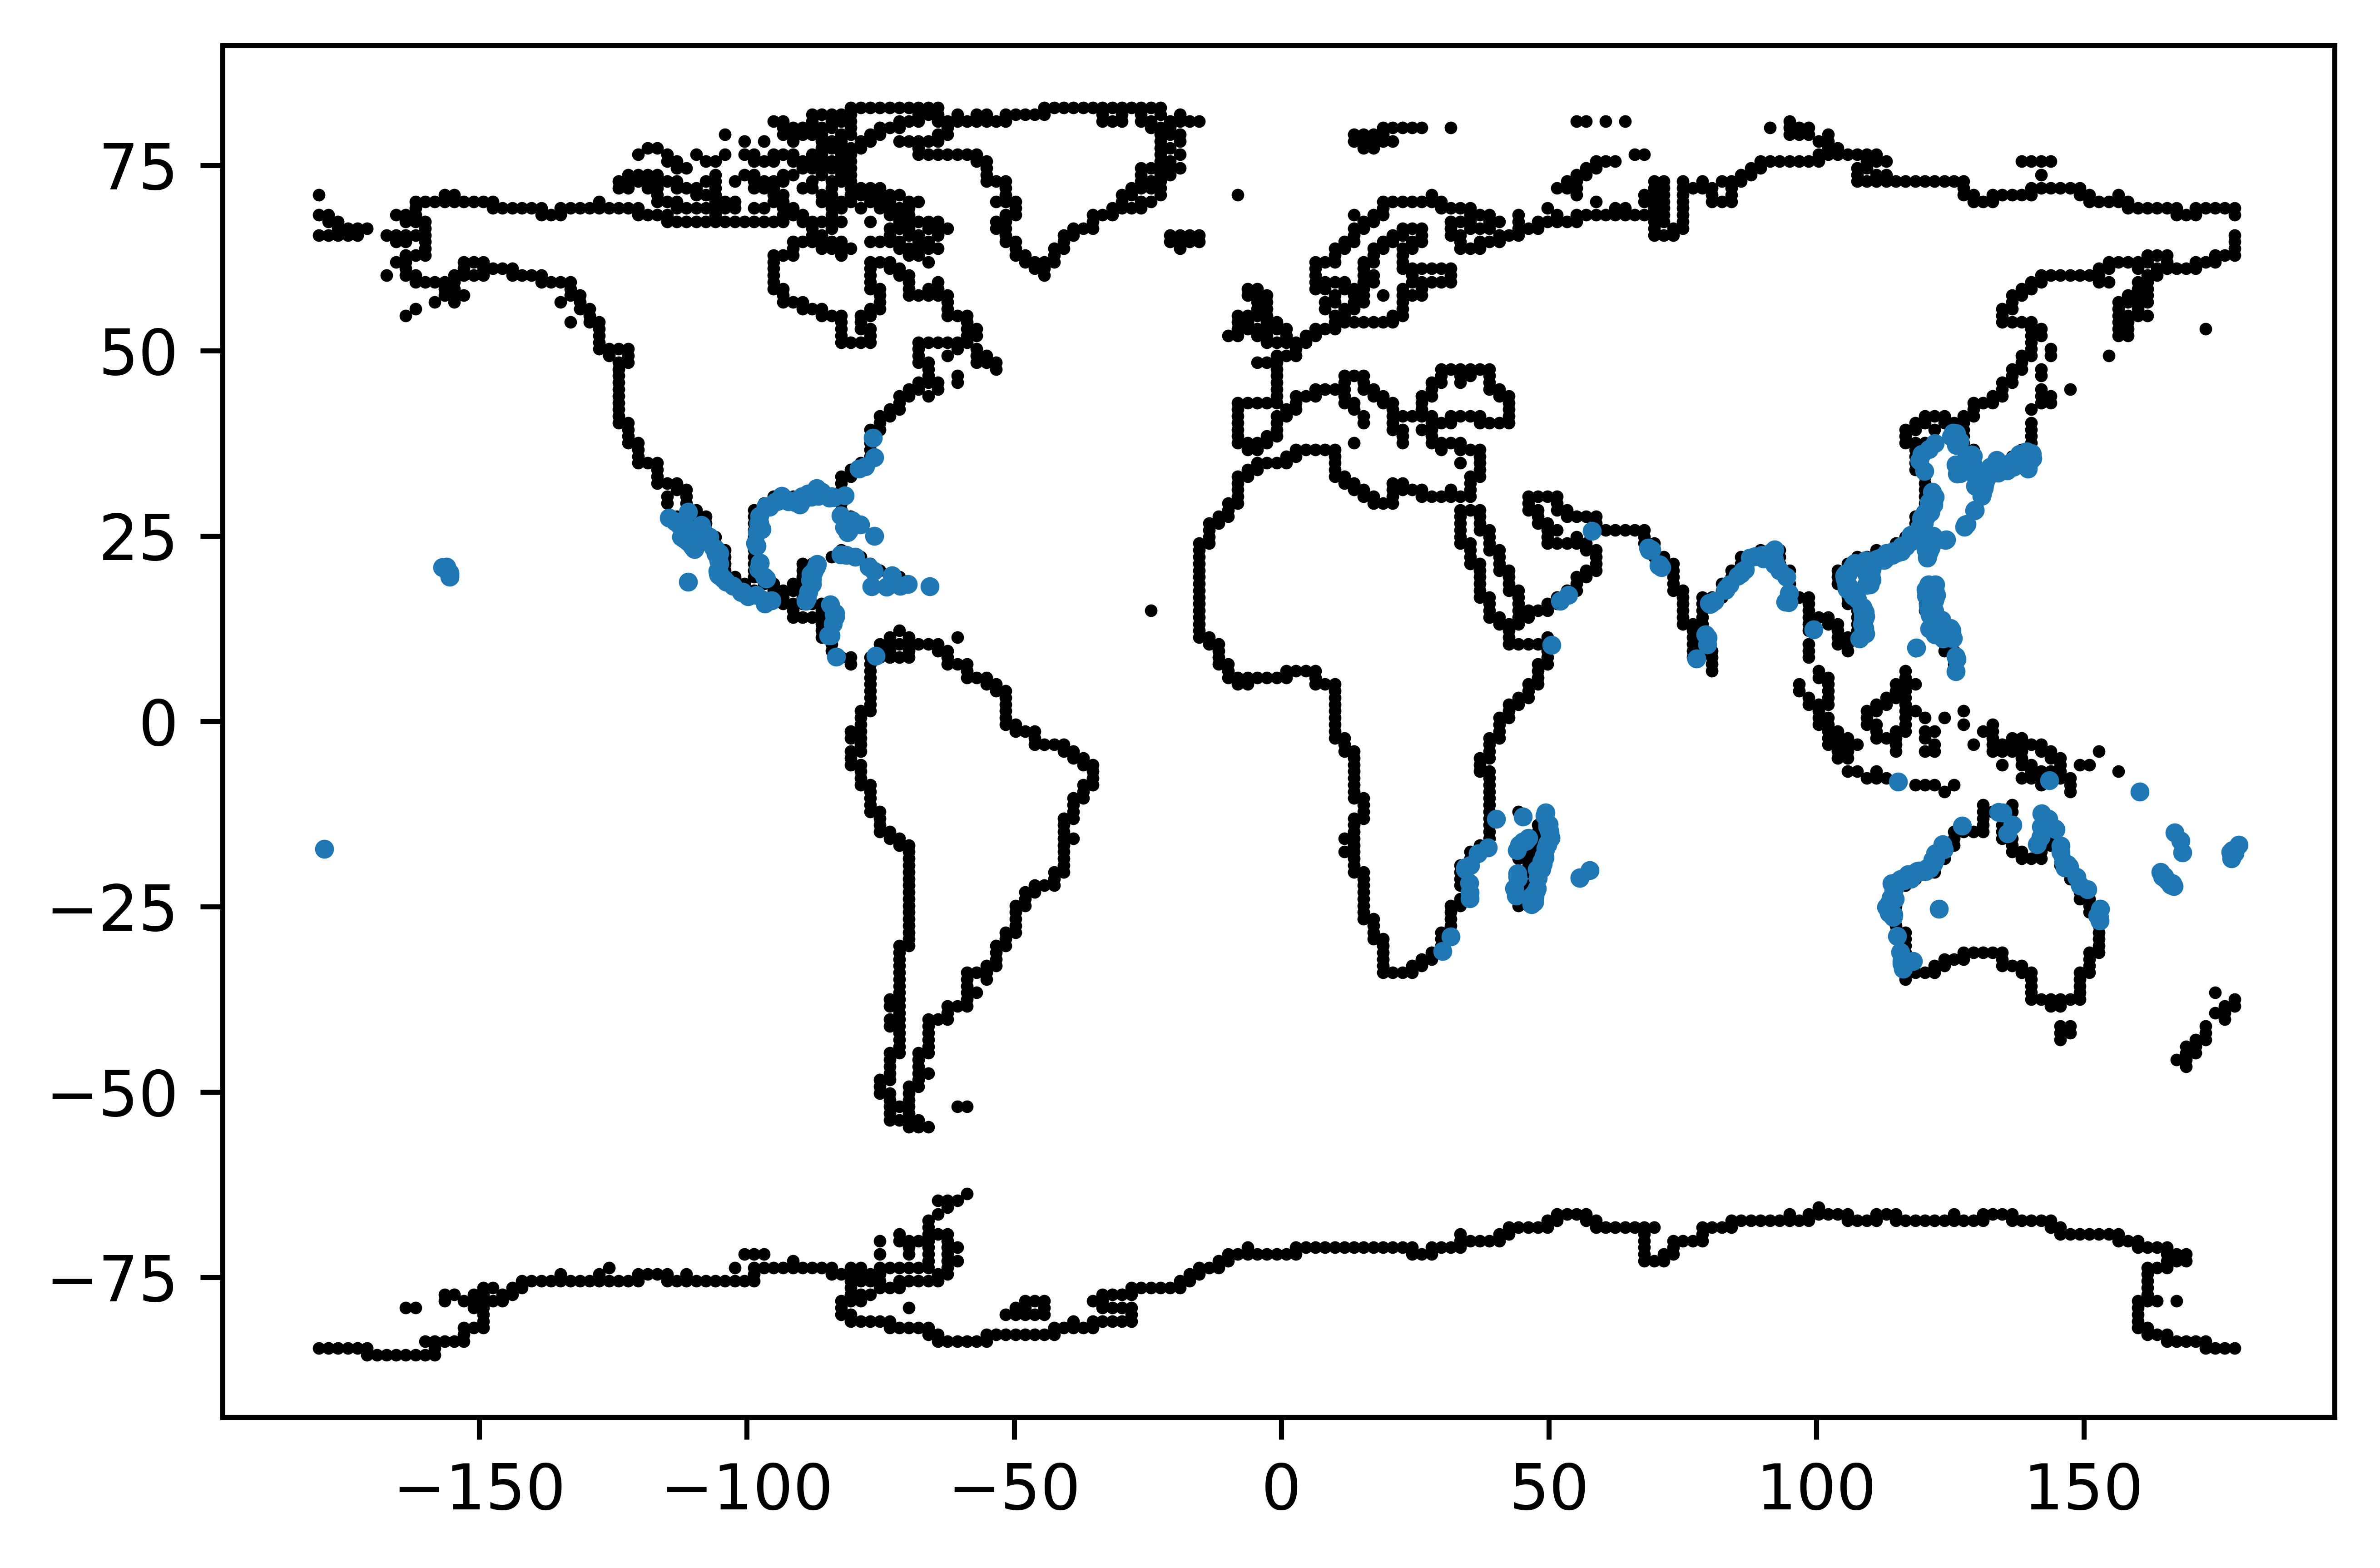

In [108]:
new_lf_lon_locs = np.array(new_lf_lon_locs)
new_lf_lat_locs = np.array(new_lf_lat_locs)


transfer_array = np.empty([len(new_lf_lat_locs)])
for i in range(0,len(new_lf_lat_locs)):
    if new_lf_lat_locs[i]>40 or new_lf_lat_locs[i]<-40:
        new_lf_lat_locs[i] = 0
        new_lf_lon_locs[i] = 0

# print(transfer_array, new_lf_lat_locs*transfer_array)
# new_lf_lat_locs = new_lf_lat_locs*transfer_array
# new_lf_lon_locs = new_lf_lon_locs*transfer_array
# print(new_lf_lon_locs,new_lf_lat_locs)
new_lf_lat_locs = new_lf_lat_locs[new_lf_lat_locs!=0]
new_lf_lon_locs = new_lf_lon_locs[new_lf_lon_locs!=0]
landmap(-180,180,-90,90)
plt.scatter(new_lf_lon_locs,new_lf_lat_locs, s = 4)

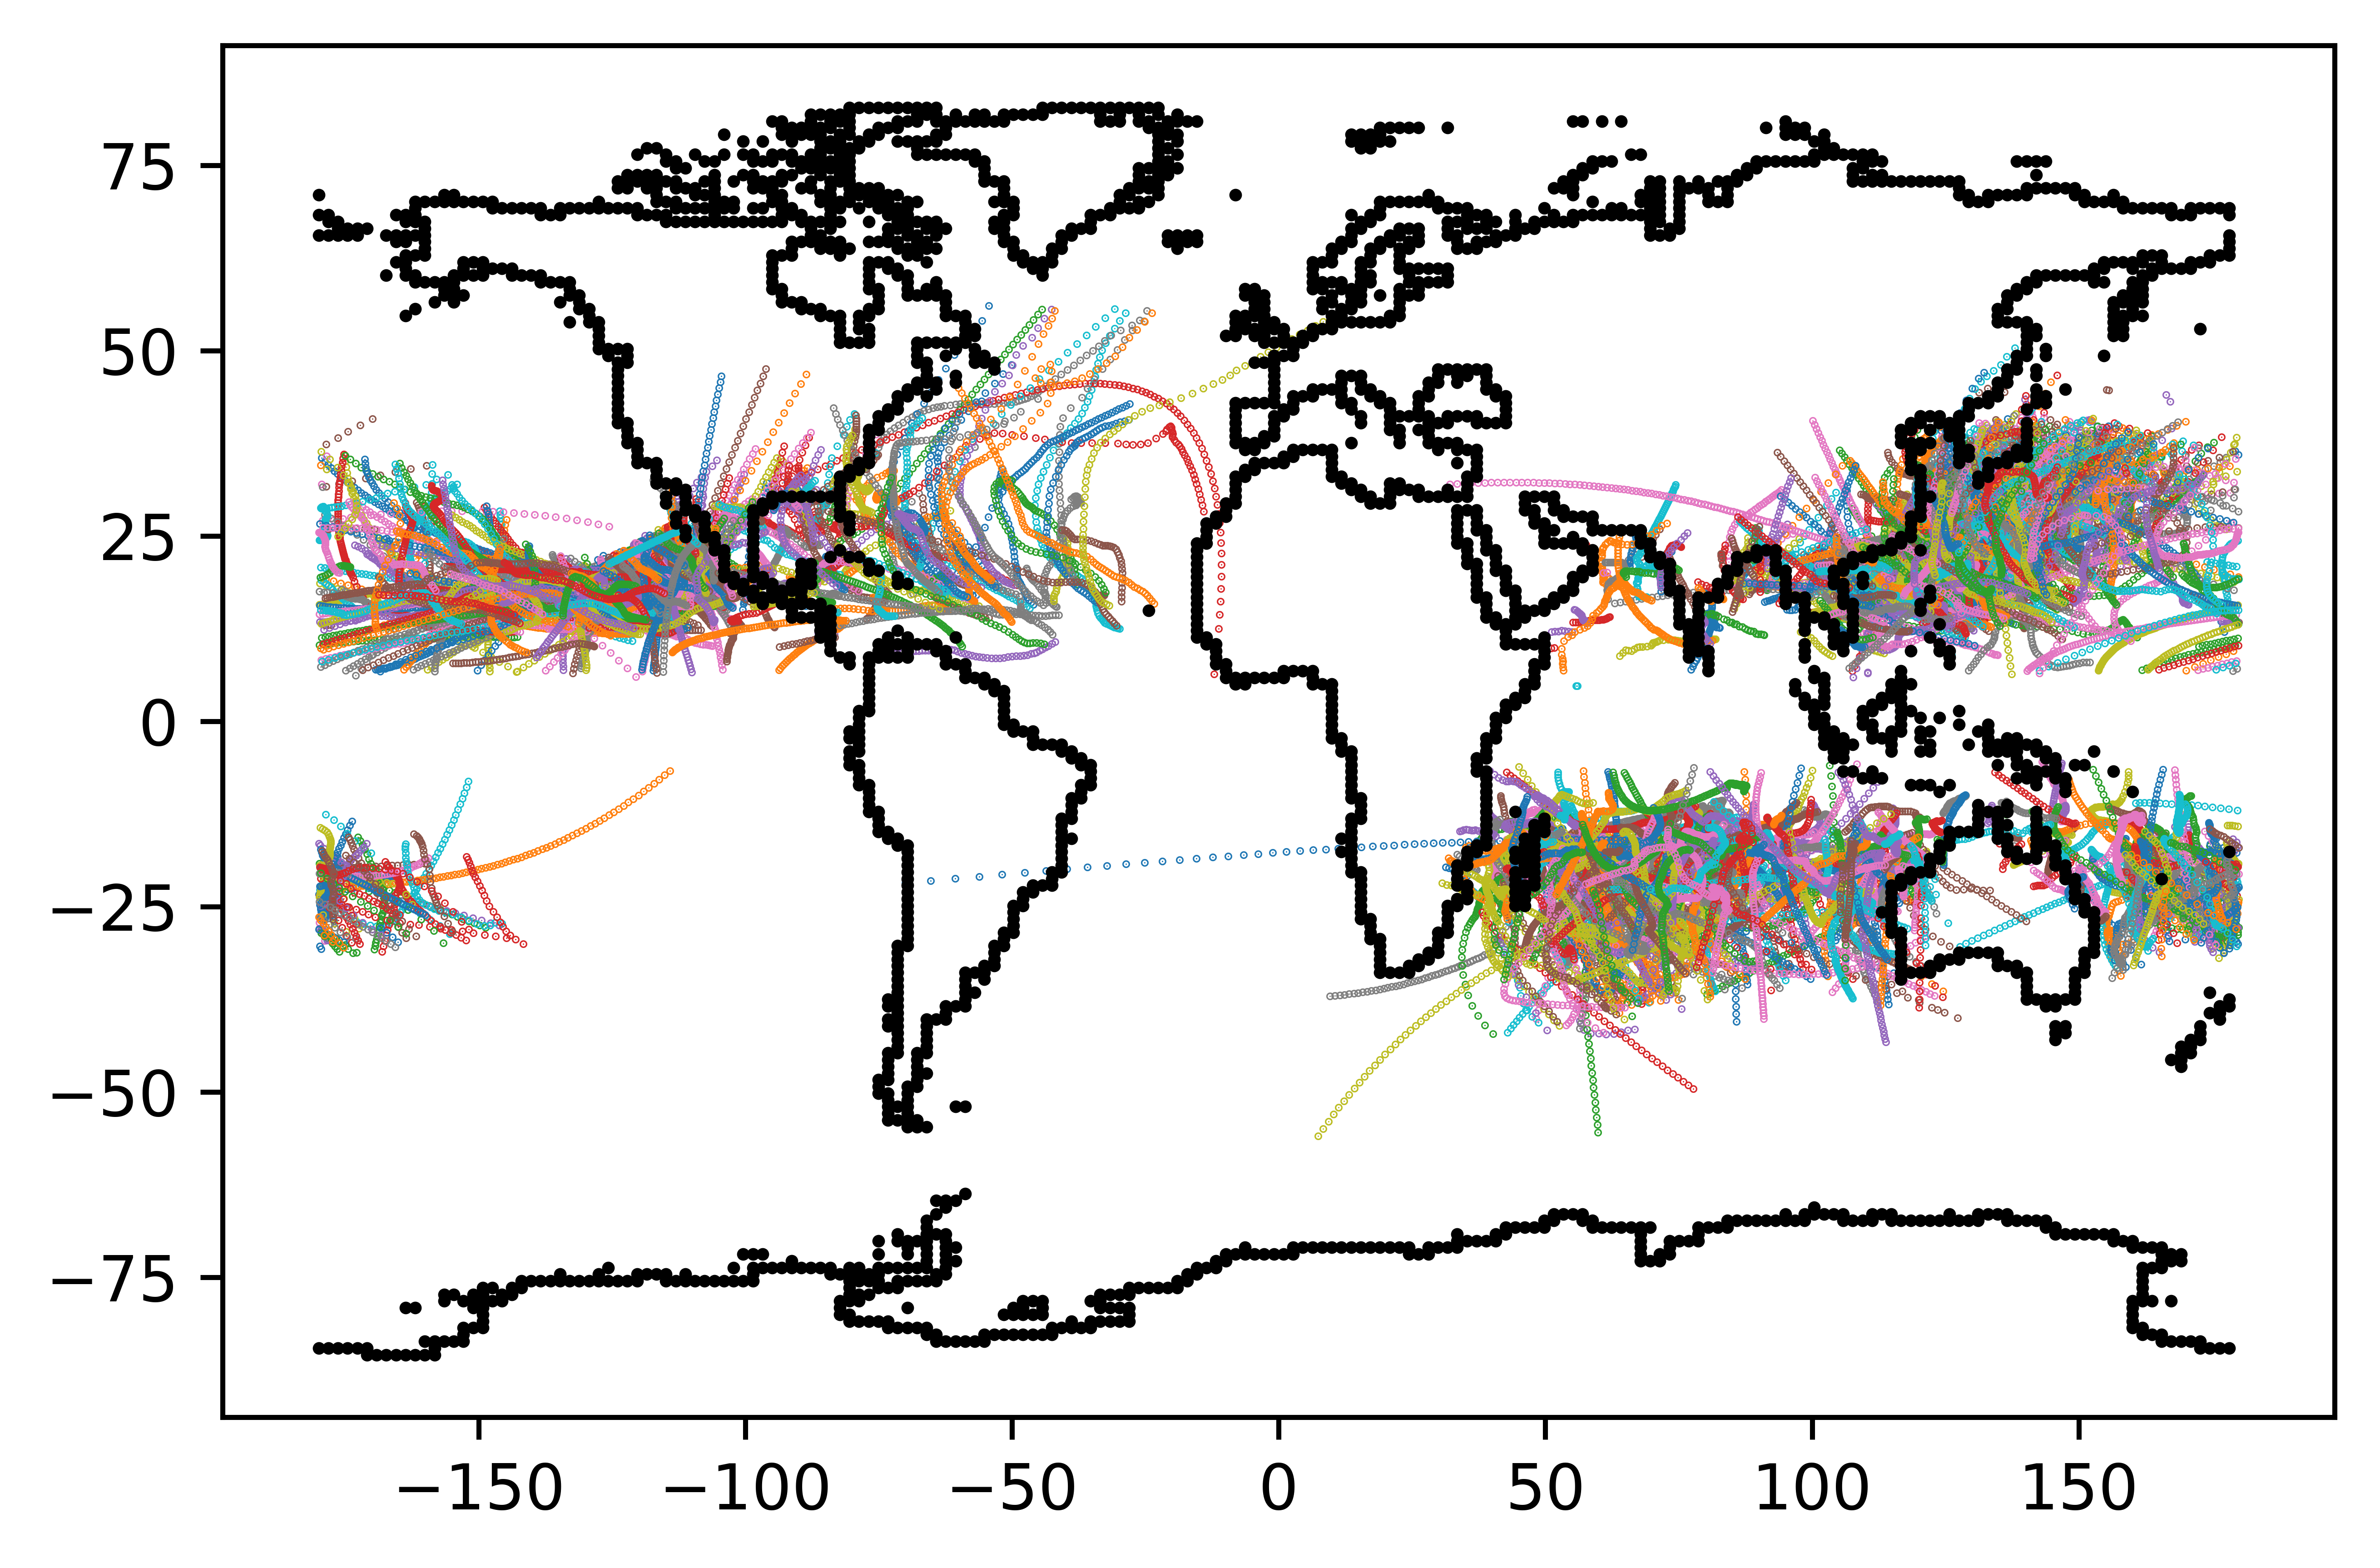

In [136]:
plt.figure(1)
for i in range(0,len(sim_lons)):
    plt.scatter(np.array(sim_lons[i][0]),np.array(sim_lats[i][0]),s=0.05)
landmap(-180,180,-90,90)